# MDL Assignment 4 — Part B: Markov Decision Process
**Deadline:** April 18th, 2026

---

## Grid World Setup

```
y=3 | WALL  | (1,3) | RED   | GREEN |
y=2 | (0,2) | (1,2) | (2,2) | (3,2) |
y=1 | (0,1) | WALL  | (2,1) | WALL  |
y=0 | (0,0) | (1,0) | (2,0) | (3,0) |
      x=0     x=1     x=2     x=3
```

**Cell types:**
- `(3,3)` — REWARD (Green), sink state: reward = **+1**
- `(2,3)` — PENALTY (Red), sink state: reward = **−1**
- `(0,3), (1,1), (3,1)` — WALL (blocked)
- All others — Normal states, step cost = **−0.04**

**Movement model (intended direction with prob p):**
- P(intended) = p
- P(perpendicular left/right) = (1−p)/2 each
- P(opposite) = 0
- If a move hits a wall/boundary → agent stays in place

**Discount factor γ = 0.95**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm

# ── Grid World Constants ───────────────────────────────────────────────────
GRID_W, GRID_H = 4, 4

WALL    = set([(0,3), (1,1), (3,1)])     # blocked cells
REWARD  = (3,3)                           # green  +1
PENALTY = (2,3)                           # red   -1
TERMINALS = {REWARD: 1.0, PENALTY: -1.0} # sink states with their utility

STEP_COST = -0.04
GAMMA     = 0.95
CONVERGE  = 0.0001

ACTIONS = ['up', 'down', 'left', 'right']

# Direction vectors: (dx, dy)
DELTA = {
    'up'   : ( 0,  1),
    'down' : ( 0, -1),
    'left' : (-1,  0),
    'right': ( 1,  0),
}

# Perpendicular actions for each action
PERPENDICULAR = {
    'up'   : ['left', 'right'],
    'down' : ['left', 'right'],
    'left' : ['up', 'down'],
    'right': ['up', 'down'],
}


def valid_states():
    """Return all non-wall, non-terminal state coordinates."""
    states = []
    for x in range(GRID_W):
        for y in range(GRID_H):
            if (x, y) not in WALL and (x, y) not in TERMINALS:
                states.append((x, y))
    return states


def try_move(state, action):
    """Return resulting state after attempting action from state.
    If move is blocked by boundary or wall, agent stays.
    """
    dx, dy = DELTA[action]
    nx, ny = state[0] + dx, state[1] + dy
    if 0 <= nx < GRID_W and 0 <= ny < GRID_H and (nx, ny) not in WALL:
        return (nx, ny)
    return state  # blocked: stay


def transition(state, action, p):
    """Return list of (probability, next_state) for taking action from state."""
    outcomes = []
    # Intended direction
    outcomes.append((p, try_move(state, action)))
    # Perpendicular directions
    for perp in PERPENDICULAR[action]:
        outcomes.append(((1 - p) / 2, try_move(state, perp)))
    return outcomes


print("Grid world helper functions defined.")
print(f"Non-terminal, non-wall states: {valid_states()}")

Grid world helper functions defined.
Non-terminal, non-wall states: [(0, 0), (0, 1), (0, 2), (1, 0), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (3, 0), (3, 2)]


/home/prasad/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## Question 1 — Value Iteration [70 Marks]

### Task A — Value Iteration for p = 0.7 [20 Marks]

Run Value Iteration and print the **utility of each cell after every iteration** until convergence (max change ≤ 0.0001).

**Bellman update:**
$$U_{t+1}(s) = \max_a \left[ C(s,a) + \gamma \sum_{s'} P(s'|s,a)\, U_t(s') \right]$$

In [2]:
def value_iteration(p, verbose=True):
    """
    Run Value Iteration on the 4x4 grid.
    
    Parameters
    ----------
    p       : float  — probability of moving in intended direction
    verbose : bool   — if True, print utility grid after each iteration
    
    Returns
    -------
    U      : dict  — final utility values  {(x,y): value}
    policy : dict  — optimal policy        {(x,y): action_string}
    iters  : int   — number of iterations to converge
    """
    # Initialise
    U = {}
    for x in range(GRID_W):
        for y in range(GRID_H):
            if (x, y) in WALL:
                U[(x, y)] = None
            elif (x, y) in TERMINALS:
                U[(x, y)] = TERMINALS[(x, y)]  # fixed terminal utility
            else:
                U[(x, y)] = 0.0

    states = valid_states()
    iteration = 0

    def print_grid(U, iteration):
        """Pretty print the 4x4 utility grid."""
        print(f"\n{'─'*55}")
        print(f"  Iteration {iteration}  (p={p})")
        print(f"{'─'*55}")
        print(f"  {'x=0':>10} {'x=1':>10} {'x=2':>10} {'x=3':>10}")
        for y in range(GRID_H - 1, -1, -1):
            row = f"y={y} "
            for x in range(GRID_W):
                v = U[(x, y)]
                if v is None:
                    row += f"{'[WALL]':>10}"
                elif (x, y) == REWARD:
                    row += f"{'[+1.00]':>10}"
                elif (x, y) == PENALTY:
                    row += f"{'[-1.00]':>10}"
                else:
                    row += f"{v:>10.4f}"
            print(row)
        print()

    if verbose:
        print_grid(U, 0)

    while True:
        U_new = dict(U)  # copy
        max_delta = 0.0
        iteration += 1

        for state in states:
            best_q = -np.inf
            for action in ACTIONS:
                # Q(s, a) = C(s, a) + γ Σ P(s'|s,a) U(s')
                q = STEP_COST  # C(s, a) is step cost for normal states
                for prob, next_s in transition(state, action, p):
                    q += GAMMA * prob * U[next_s]
                if q > best_q:
                    best_q = q
            U_new[state] = best_q
            max_delta = max(max_delta, abs(best_q - U[state]))

        U = U_new
        if verbose:
            print_grid(U, iteration)

        if max_delta <= CONVERGE:
            break

    # Extract optimal policy
    policy = {}
    for x in range(GRID_W):
        for y in range(GRID_H):
            if (x, y) in WALL or (x, y) in TERMINALS:
                policy[(x, y)] = 'none'
            else:
                best_action, best_q = None, -np.inf
                for action in ACTIONS:
                    q = STEP_COST
                    for prob, next_s in transition((x, y), action, p):
                        q += GAMMA * prob * U[next_s]
                    if q > best_q:
                        best_q = q
                        best_action = action
                policy[(x, y)] = best_action

    return U, policy, iteration


# ── Run for p = 0.7 ──────────────────────────────────────────────
print("Running Value Iteration for p = 0.7...")
print("(Utility values initialised to 0 for non-terminal states)")
U_07, policy_07, iters_07 = value_iteration(p=0.7, verbose=True)
print(f"\nConverged after {iters_07} iterations (p=0.7)")

Running Value Iteration for p = 0.7...
(Utility values initialised to 0 for non-terminal states)

───────────────────────────────────────────────────────
  Iteration 0  (p=0.7)
───────────────────────────────────────────────────────
         x=0        x=1        x=2        x=3
y=3     [WALL]    0.0000   [-1.00]   [+1.00]
y=2     0.0000    0.0000    0.0000    0.0000
y=1     0.0000    [WALL]    0.0000    [WALL]
y=0     0.0000    0.0000    0.0000    0.0000


───────────────────────────────────────────────────────
  Iteration 1  (p=0.7)
───────────────────────────────────────────────────────
         x=0        x=1        x=2        x=3
y=3     [WALL]   -0.0400   [-1.00]   [+1.00]
y=2    -0.0400   -0.0400   -0.0400    0.6250
y=1    -0.0400    [WALL]   -0.0400    [WALL]
y=0    -0.0400   -0.0400   -0.0400   -0.0400


───────────────────────────────────────────────────────
  Iteration 2  (p=0.7)
───────────────────────────────────────────────────────
         x=0        x=1        x=2       

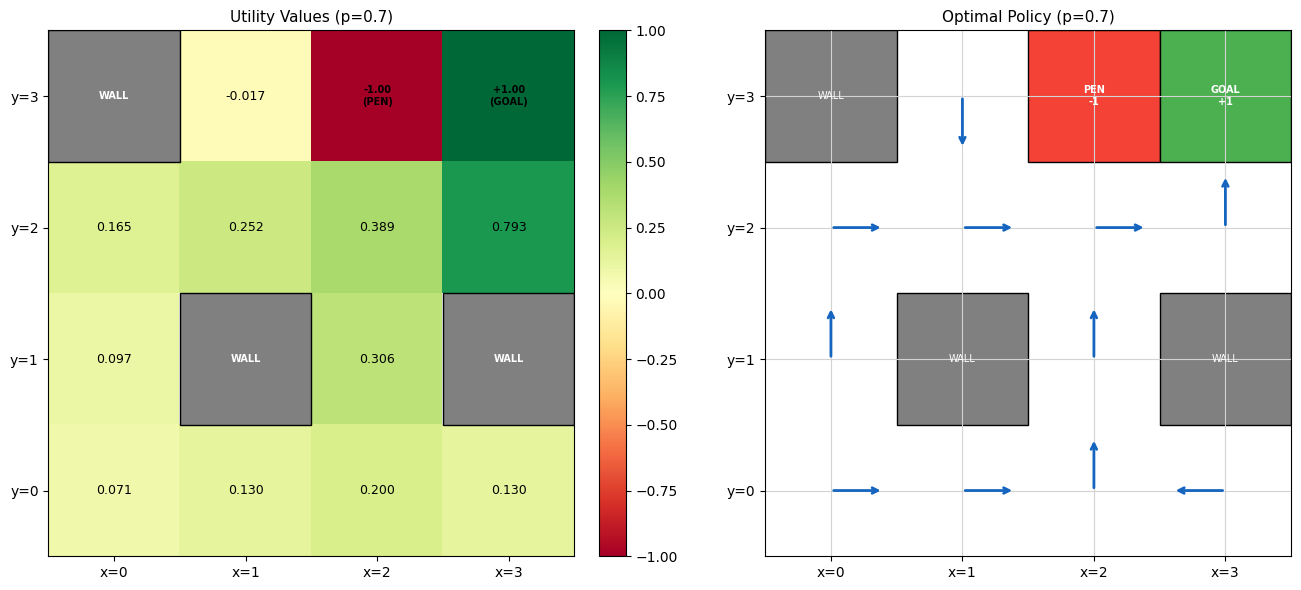

Saved mdp_p07.png


In [3]:
# ── Visualise Final Utilities & Policy for p=0.7 ──────────────────────────

def plot_utility_policy(U, policy, p, ax_u, ax_p):
    """Draw heatmap of utilities and policy arrows on given axes."""
    arrow_map = {'up': (0, 0.4), 'down': (0, -0.4), 'left': (-0.4, 0), 'right': (0.4, 0)}

    # ── Utility heatmap
    grid_vals = np.full((GRID_H, GRID_W), np.nan)
    for x in range(GRID_W):
        for y in range(GRID_H):
            if U[(x, y)] is not None:
                grid_vals[GRID_H - 1 - y][x] = U[(x, y)]

    im = ax_u.imshow(grid_vals, cmap='RdYlGn', vmin=-1, vmax=1, aspect='equal')
    plt.colorbar(im, ax=ax_u, fraction=0.046, pad=0.04)

    for x in range(GRID_W):
        for y in range(GRID_H):
            row = GRID_H - 1 - y
            if (x, y) in WALL:
                ax_u.add_patch(plt.Rectangle((x - 0.5, row - 0.5), 1, 1,
                                              facecolor='gray', edgecolor='black'))
                ax_u.text(x, row, 'WALL', ha='center', va='center',
                          fontsize=7, color='white', fontweight='bold')
            elif (x, y) == REWARD:
                ax_u.text(x, row, f'+1.00\n(GOAL)', ha='center', va='center',
                          fontsize=7, color='black', fontweight='bold')
            elif (x, y) == PENALTY:
                ax_u.text(x, row, f'-1.00\n(PEN)', ha='center', va='center',
                          fontsize=7, color='black', fontweight='bold')
            else:
                ax_u.text(x, row, f'{U[(x,y)]:.3f}', ha='center', va='center',
                          fontsize=9, color='black')

    ax_u.set_xticks(range(GRID_W))
    ax_u.set_xticklabels([f'x={i}' for i in range(GRID_W)])
    ax_u.set_yticks(range(GRID_H))
    ax_u.set_yticklabels([f'y={GRID_H-1-i}' for i in range(GRID_H)])
    ax_u.set_title(f'Utility Values (p={p})', fontsize=11)

    # ── Policy arrows
    ax_p.set_xlim(-0.5, GRID_W - 0.5)
    ax_p.set_ylim(-0.5, GRID_H - 0.5)
    ax_p.set_aspect('equal')
    ax_p.grid(True, which='both', color='lightgray')
    ax_p.set_xticks(range(GRID_W))
    ax_p.set_yticks(range(GRID_H))
    ax_p.set_xticklabels([f'x={i}' for i in range(GRID_W)])
    ax_p.set_yticklabels([f'y={i}' for i in range(GRID_H)])
    ax_p.set_title(f'Optimal Policy (p={p})', fontsize=11)

    for x in range(GRID_W):
        for y in range(GRID_H):
            if (x, y) in WALL:
                ax_p.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                              facecolor='gray', edgecolor='black'))
                ax_p.text(x, y, 'WALL', ha='center', va='center',
                          fontsize=7, color='white')
            elif (x, y) == REWARD:
                ax_p.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                              facecolor='#4CAF50', edgecolor='black'))
                ax_p.text(x, y, 'GOAL\n+1', ha='center', va='center',
                          fontsize=7, color='white', fontweight='bold')
            elif (x, y) == PENALTY:
                ax_p.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1,
                                              facecolor='#F44336', edgecolor='black'))
                ax_p.text(x, y, 'PEN\n-1', ha='center', va='center',
                          fontsize=7, color='white', fontweight='bold')
            else:
                act = policy[(x, y)]
                if act in arrow_map:
                    dx, dy = arrow_map[act]
                    ax_p.annotate('', xy=(x + dx, y + dy), xytext=(x, y),
                                   arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_utility_policy(U_07, policy_07, p=0.7, ax_u=axes[0], ax_p=axes[1])
plt.tight_layout()
plt.savefig("mdp_p07.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved mdp_p07.png")

---
### Task B — Policy for p ∈ {0.1, 0.2, ..., 0.9} [50 Marks]

In [4]:
# ── Run Value Iteration for all p values ──────────────────────────────────

P_VALUES = [round(p, 1) for p in np.arange(0.1, 1.0, 0.1)]
all_results = {}  # {p: (U, policy, iters)}

print("Running Value Iteration for p in [0.1, 0.9]...\n")
for p in P_VALUES:
    U, policy, iters = value_iteration(p=p, verbose=False)
    all_results[p] = (U, policy, iters)
    print(f"  p={p:.1f}: converged in {iters} iterations")

print("\nDone!")

Running Value Iteration for p in [0.1, 0.9]...

  p=0.1: converged in 52 iterations
  p=0.2: converged in 53 iterations
  p=0.3: converged in 53 iterations
  p=0.4: converged in 53 iterations
  p=0.5: converged in 49 iterations
  p=0.6: converged in 30 iterations
  p=0.7: converged in 23 iterations
  p=0.8: converged in 19 iterations
  p=0.9: converged in 15 iterations

Done!


In [5]:
# ── Print Final Converged Policies in 4x4 Grid Format ────────────────────

def print_policy_grid(policy, p):
    """Print policy as a 4x4 grid (top row = y=3)."""
    print(f"\n{'═'*52}")
    print(f"  Converged Policy for p = {p:.1f}")
    print(f"{'═'*52}")
    for y in range(GRID_H - 1, -1, -1):
        row_vals = []
        for x in range(GRID_W):
            row_vals.append(f"'{policy[(x,y)]}'")
        print("  " + "  ".join(f"{v:>8}" for v in row_vals))
    print()


for p in P_VALUES:
    _, policy, _ = all_results[p]
    print_policy_grid(policy, p)


════════════════════════════════════════════════════
  Converged Policy for p = 0.1
════════════════════════════════════════════════════
    'none'    'left'    'none'    'none'
      'up'    'down'    'down'   'right'
    'left'    'none'    'left'    'none'
   'right'      'up'   'right'      'up'


════════════════════════════════════════════════════
  Converged Policy for p = 0.2
════════════════════════════════════════════════════
    'none'    'left'    'none'    'none'
      'up'    'down'    'down'   'right'
    'left'    'none'      'up'    'none'
   'right'      'up'   'right'      'up'


════════════════════════════════════════════════════
  Converged Policy for p = 0.3
════════════════════════════════════════════════════
    'none'    'left'    'none'    'none'
      'up'    'down'    'down'   'right'
      'up'    'none'      'up'    'none'
   'right'   'right'   'right'      'up'


════════════════════════════════════════════════════
  Converged Policy for p = 0.4
══════

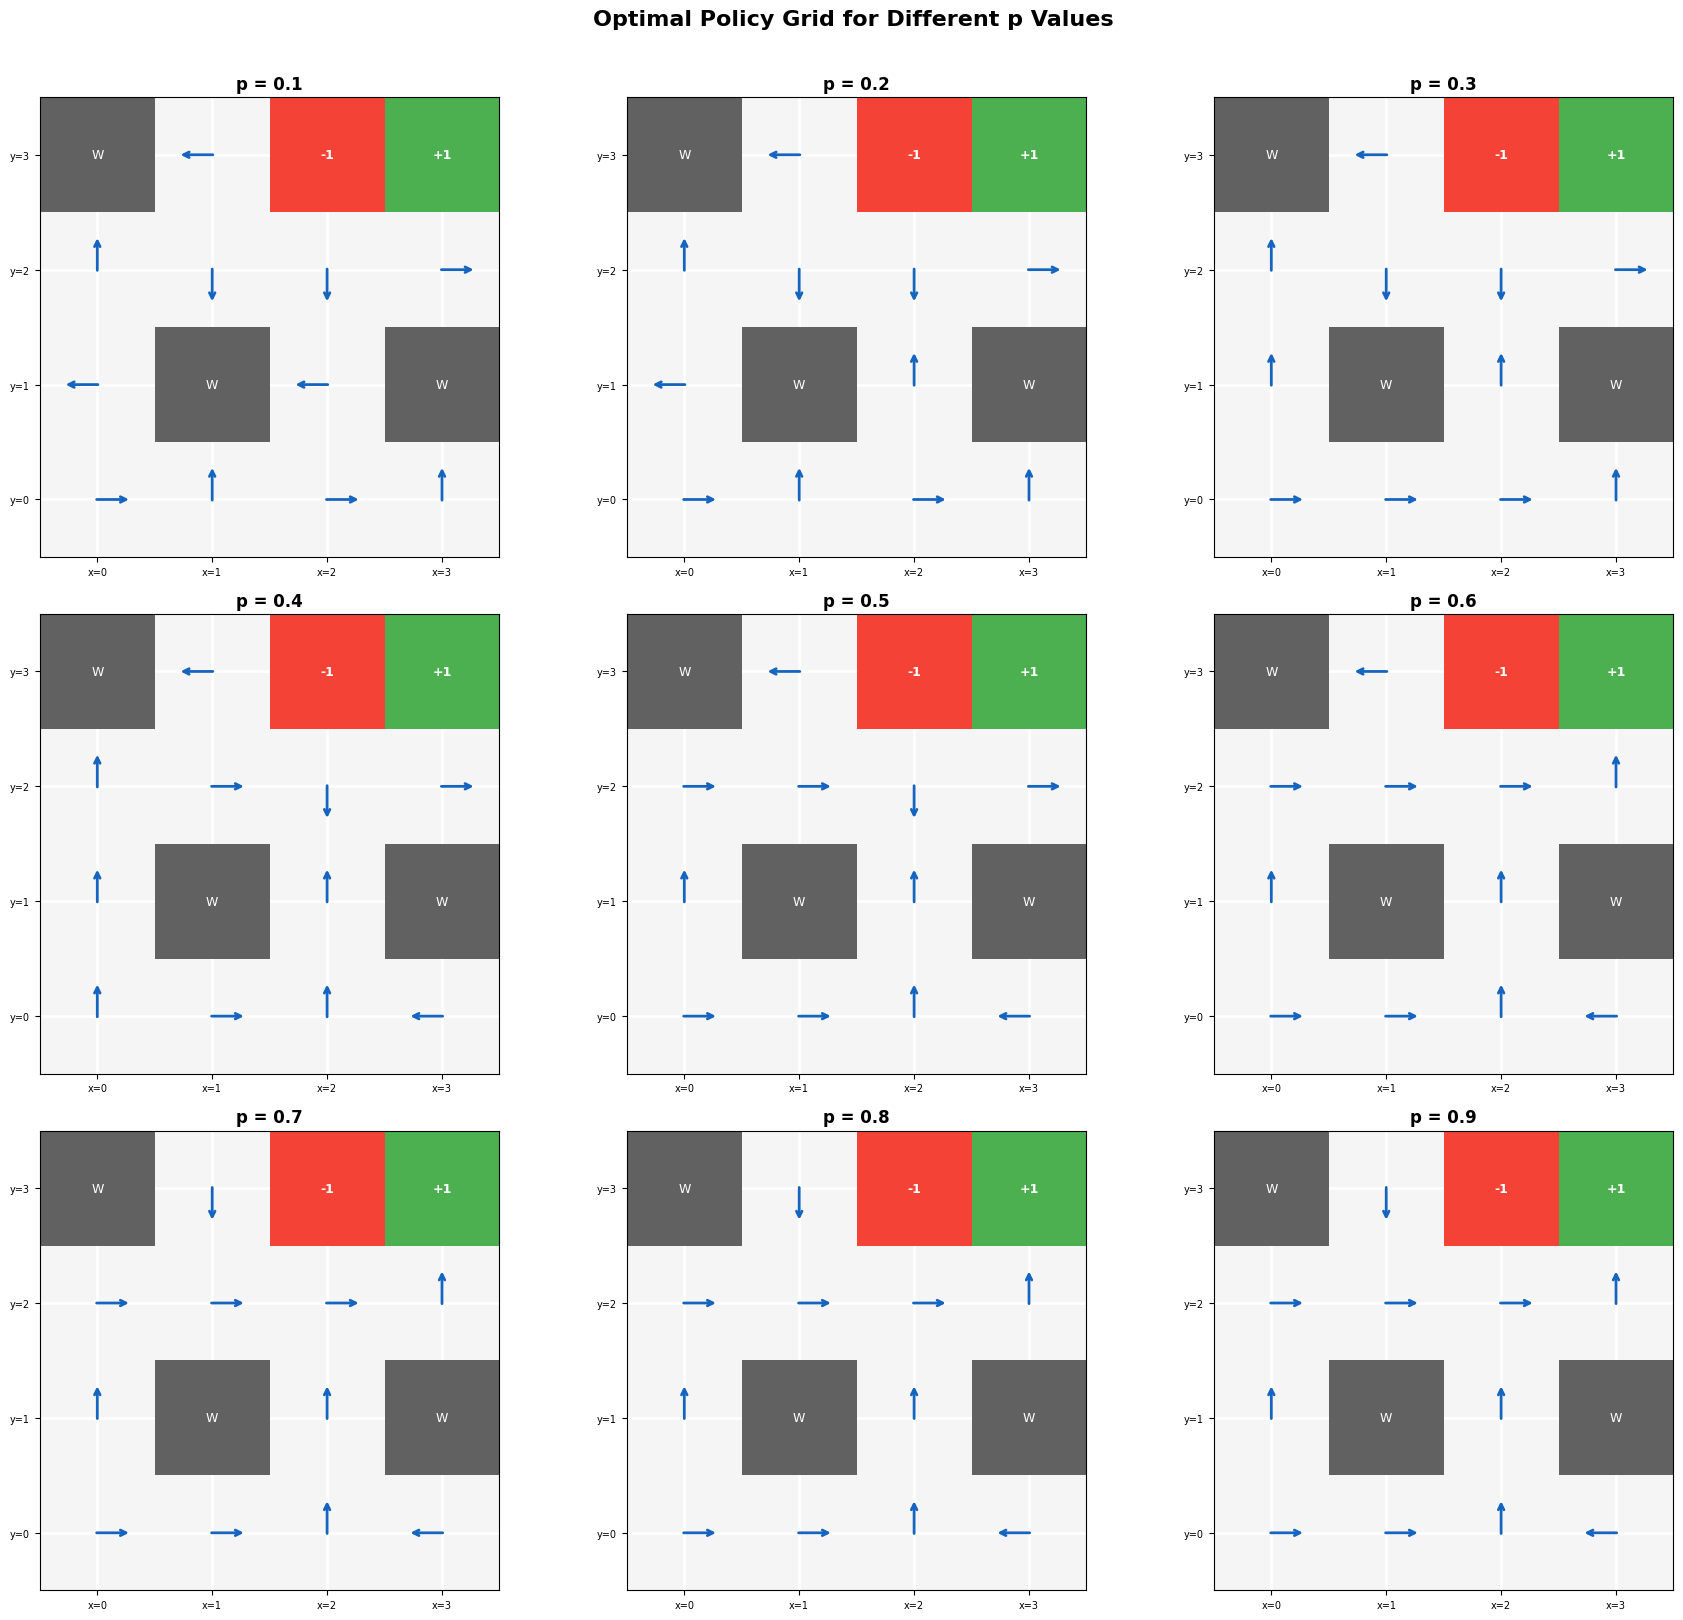

Saved policy_grid_all_p.png


In [6]:
# ── Visualise Policies for all p in a Grid ────────────────────────────────

arrow_map = {'up': (0, 0.3), 'down': (0, -0.3), 'left': (-0.3, 0), 'right': (0.3, 0)}

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.suptitle("Optimal Policy Grid for Different p Values", fontsize=16, fontweight='bold', y=1.01)

for ax, p in zip(axes.flat, P_VALUES):
    _, policy, _ = all_results[p]

    ax.set_xlim(-0.5, GRID_W - 0.5)
    ax.set_ylim(-0.5, GRID_H - 0.5)
    ax.set_aspect('equal')
    ax.set_facecolor('#F5F5F5')
    ax.grid(True, color='white', linewidth=2)
    ax.set_xticks(range(GRID_W))
    ax.set_yticks(range(GRID_H))
    ax.set_xticklabels([f'x={i}' for i in range(GRID_W)], fontsize=7)
    ax.set_yticklabels([f'y={i}' for i in range(GRID_H)], fontsize=7)
    ax.set_title(f'p = {p:.1f}', fontsize=12, fontweight='bold')

    for x in range(GRID_W):
        for y in range(GRID_H):
            if (x, y) in WALL:
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                                            facecolor='#616161', zorder=2))
                ax.text(x, y, 'W', ha='center', va='center',
                        fontsize=9, color='white', zorder=3)
            elif (x, y) == REWARD:
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                                            facecolor='#4CAF50', zorder=2))
                ax.text(x, y, '+1', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold', zorder=3)
            elif (x, y) == PENALTY:
                ax.add_patch(plt.Rectangle((x-0.5, y-0.5), 1, 1,
                                            facecolor='#F44336', zorder=2))
                ax.text(x, y, '-1', ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold', zorder=3)
            else:
                act = policy[(x, y)]
                if act in arrow_map:
                    dx, dy = arrow_map[act]
                    ax.annotate('', xy=(x+dx, y+dy), xytext=(x-dx*0.1, y-dy*0.1),
                                 arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2),
                                 zorder=3)

plt.tight_layout()
plt.savefig("policy_grid_all_p.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved policy_grid_all_p.png")

---
## Analysis: How Does Policy Change with p?

### Observations

**The parameter p controls the agent's movement reliability** — higher p means the agent moves in its intended direction more often.

#### Low p (0.1 – 0.3): Highly stochastic environment
- Movement is very unpredictable: the agent moves in the intended direction only 10–30% of the time, but perpendicular movements each occur with probability (1-p)/2 ≈ 35–45%.
- The policy becomes **more conservative and risk-averse**: cells near the PENALTY state (2,3) direct the agent **away** and tend to prefer routes that don't risk slipping into the red state.
- Some cells deep in the bottom-left may prefer to navigate cautiously around walls rather than approach the top row.

#### Moderate p (0.4 – 0.6): Transitional behaviour
- A mix of caution and directness. The agent starts taking more direct routes toward the REWARD (3,3).
- Cells adjacent to the PENALTY may switch policy direction as the risk of accidentally entering (-1) decreases.

#### High p (0.7 – 0.9): Near-deterministic environment
- The agent is confident it will move where intended.
- Policies converge to **nearly straight-line paths** toward the GOAL state (3,3).
- The penalty state is easily avoided since perpendicular slip probability is low: (1-0.9)/2 = 5%.
- Most navigable cells point 'right' or 'up' toward the goal via efficient paths.

### Why Does This Happen? — The Risk-Reward Trade-off

The Bellman equation balances:
1. **Expected reward** — moving toward (3,3) gives +1, but passing near (2,3) risks -1.
2. **Stochastic slip** — with low p, even trying to go 'right' near row y=3 risks slipping 'up' into the penalty cell.

**At low p**, the probability-weighted disutility from potentially entering the PENALTY cell is high, so the optimal policy routes the agent through longer but safer paths (e.g., going around via y=0 → y=3 approach from the right side).

**At high p**, the agent can reliably avoid the penalty cell, so the direct route is optimal.

> **Key Insight:** As p increases, the policy transitions from risk-averse indirect routing to risk-accepting direct routing — a direct manifestation of how **movement uncertainty shapes decision-making** in MDPs.

---
## Question 2 — Manual 2-Iteration Verification [30 Marks]

*Full handwritten calculations are in `roll_no.pdf`. The code below verifies the first 2 iterations computationally.*

In [7]:
# ── Verify first 2 iterations for p=0.7 ──────────────────────────────────
# This cell prints the utility grids after iteration 1 and 2
# to help verify the manual handwritten calculations.

print("Verification: Utility values after Iteration 1 and 2 (p=0.7)")
print("These values should match your handwritten calculations.\n")

p = 0.7
U_verify = {}
for x in range(GRID_W):
    for y in range(GRID_H):
        if (x, y) in WALL:
            U_verify[(x, y)] = None
        elif (x, y) in TERMINALS:
            U_verify[(x, y)] = TERMINALS[(x, y)]
        else:
            U_verify[(x, y)] = 0.0

states = valid_states()

for it in range(1, 3):
    U_new = dict(U_verify)
    for state in states:
        best_q = -np.inf
        for action in ACTIONS:
            q = STEP_COST
            for prob, next_s in transition(state, action, p):
                q += GAMMA * prob * U_verify[next_s]
            if q > best_q:
                best_q = q
        U_new[state] = best_q
    U_verify = U_new

    print(f"{'─'*55}")
    print(f"  After Iteration {it}:")
    print(f"{'─'*55}")
    print(f"  {'x=0':>10} {'x=1':>10} {'x=2':>10} {'x=3':>10}")
    for y in range(GRID_H - 1, -1, -1):
        row = f"y={y} "
        for x in range(GRID_W):
            v = U_verify[(x, y)]
            if v is None:
                row += f"{'[WALL]':>10}"
            elif (x, y) == REWARD:
                row += f"{'[+1.000]':>10}"
            elif (x, y) == PENALTY:
                row += f"{'[-1.000]':>10}"
            else:
                row += f"{v:>10.4f}"
        print(row)
    print()

Verification: Utility values after Iteration 1 and 2 (p=0.7)
These values should match your handwritten calculations.

───────────────────────────────────────────────────────
  After Iteration 1:
───────────────────────────────────────────────────────
         x=0        x=1        x=2        x=3
y=3     [WALL]   -0.0400  [-1.000]  [+1.000]
y=2    -0.0400   -0.0400   -0.0400    0.6250
y=1    -0.0400    [WALL]   -0.0400    [WALL]
y=0    -0.0400   -0.0400   -0.0400   -0.0400

───────────────────────────────────────────────────────
  After Iteration 2:
───────────────────────────────────────────────────────
         x=0        x=1        x=2        x=3
y=3     [WALL]   -0.0780  [-1.000]  [+1.000]
y=2    -0.0780   -0.0780    0.2274    0.7084
y=1    -0.0780    [WALL]   -0.0780    [WALL]
y=0    -0.0780   -0.0780   -0.0780   -0.0780

